# 一维 PEMFC 瞬态自冷启动模型（修正版）

本 Notebook 实现五层膜电极（aGDL/aCL/PEM/cCL/cGDL）的单元中心有限体积模型。多孔层分别求解水蒸气、液态水和冰，PEM 单独求解吸附态膜水；并耦合气体扩散、电化学产水、三类相变、相变潜热、冰占孔、催化活性面积和电池电压。

> 说明：本文件首先保证公式、作用域、单位和守恒关系一致。默认电压参数取论文公式中的基准值，没有利用实验数据隐藏拟合；因此未校准前的电压误差不能作为最终模型验证结果。

## 方程—代码对应关系

- 气体守恒：以 $\varepsilon_g c_k$ 为守恒变量，氢气仅在 aGDL/aCL，氧气仅在 cCL/cGDL。
- 多孔区水守恒：分别求解 $m_v$、$m_l$ 和 $m_i$，相变项为 $R_{vl}$、$R_{li}$、$R_{vi}$。
- 膜水守恒：仅在 PEM 求解 $m_{w,\mathrm{mem}}$，包含反扩散和电渗拖曳。
- 能量守恒：包含电化学热和 $L_vR_{vl}+L_fR_{li}+(L_v+L_f)R_{vi}$。
- 电压：$V_{cell}=E_{rev}-\eta_{act}-\eta_{ohm}-\eta_{con}$。

反应产水在水蒸气与过冷液态水间的比例并非附件独立给定，代码将其作为显式闭合参数 `REACTION_WATER_LIQUID_FRACTION_COLD`；附加热容量也以 `ADDED_AREAL_HEAT_CAPACITY` 明示，不再使用原程序中不透明的体积热容倍率。

## 模型实现

In [1]:
"""One-dimensional transient PEMFC cold-start model.

The implementation follows the conservation equations used in the report:

* H2 and O2 gas-species balances in their porous domains;
* separate vapor, liquid-water and ice balances in GDL/CL;
* a separate absorbed membrane-water balance in PEM;
* explicit vapor-liquid, liquid-ice and vapor-ice phase-change sources;
* ice-dependent gas porosity, diffusivity and catalyst active area;
* energy conservation including phase-change latent heat;
* reversible voltage and activation, ohmic and concentration losses.

Space is discretized by a cell-centred finite-volume method. Diffusion and heat
conduction are advanced implicitly with tridiagonal solves. Phase change is
advanced by bounded local transfers in a symmetric (Strang) split step.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import solve_banded


# -----------------------------------------------------------------------------
# Constants and report parameters (SI units)
# -----------------------------------------------------------------------------
F = 96485.0
R = 8.314
T_REF = 298.15
P_REF = 101325.0
T_FREEZE = 273.15
E_TH = 1.48

M_WATER = 0.018
M_O2 = 31.998e-3
M_N2 = 28.014e-3
RHO_LIQUID = 990.0
RHO_ICE = 920.0
LATENT_VAPORIZATION = 2.50e6
LATENT_FREEZING = 333600.0
EPS_NUM = 1.0e-14

L_AGDL = 150.0e-6
L_ACL = 3.4e-6
L_PEM = 12.0e-6
L_CCL = 11.3e-6
L_CGDL = 150.0e-6
L_TOTAL = L_AGDL + L_ACL + L_PEM + L_CCL + L_CGDL

EPS_AGDL = 0.8
EPS_ACL = 0.3916
EPS_CCL = 0.4207
EPS_CGDL = 0.8

PERM_GDL = 6.2e-12
PERM_CL = 6.2e-13
CONTACT_ANGLE_GDL = 110.0
CONTACT_ANGLE_CL = 100.0
SURFACE_TENSION_WATER = 0.075

D_H2_REF = 1.10e-4
D_O2_REF = 2.20e-5
D_WATER_ANODE_REF = 8.69e-5
D_WATER_CATHODE_REF = 2.48e-5
DIFFUSIVITY_T_EXPONENT = 1.75
BRUGGEMAN_EXPONENT = 1.5

RHO_PEM = 2150.0
EW_PEM = 1.0
LAMBDA_INITIAL = 3.0
LAMBDA_MIN = 0.0
LAMBDA_MAX = 22.0

# Phase-change coefficients in the report/attachment.
K_CONDENSATION = 1.0
K_EVAPORATION = 1.0
K_FREEZE_LIQUID = 1.0
K_MELT_ICE = 1.0
K_DESUBLIMATION = 1.0e-4

# Reaction water phase split. Below freezing, newly generated water is treated
# as supercooled liquid in cCL and subsequently freezes through R_li. At and
# above freezing it enters the vapor balance. This explicitly defines S_v and
# S_l and avoids adding the same Faraday source to two phases.
# This is an explicit calibration/closure parameter, not a hidden voltage
# correction. 0.06 is the baseline used here; sensitivity analysis should be
# reported because the attachment does not independently identify S_v/S_l.
REACTION_WATER_LIQUID_FRACTION_COLD = 0.06

# Membrane/porous-medium interfacial kinetic closure. The prescribed interface
# value is the TOTAL water flux; internal EOD is not added a second time there.
K_MEMBRANE_TO_VAPOR = 0.001
K_VAPOR_TO_MEMBRANE = 1.0

# Voltage parameters are the values written in the report, not hidden fitted
# offsets. Calibrated alternatives should be supplied through VoltageParameters.
ALPHA = 0.5
J0_REF = 0.01
EA_ACTIVATION = 67000.0
T_J0_REF = 298.15
R_CONTACT_ASR = 0.01e-4
BETA_ICE_ACTIVE_AREA = 3.5

H_CONVECTION = 40.0

# Reduced full-cell thermal mass.  Set to 0 for a pure-MEA model.  A value near
# 6000 J/(m2 K) represents plates/fixtures explicitly as an areal heat capacity
# and replaces the old, nonphysical multiplication of every layer rho*cp by 100.
ADDED_AREAL_HEAT_CAPACITY = 6000.0

THERMAL_H2 = (0.089, 14283.0, 0.1672)
THERMAL_O2 = (1.43, 919.31, 0.0246)
THERMAL_N2 = (1.35, 1041.5, 0.0235)
THERMAL_LIQUID = (990.0, 4182.0, 0.60)
THERMAL_ICE = (920.0, 2050.0, 2.30)
THERMAL_GDL = (185.0, 545.0, 0.30)
THERMAL_CL = (970.0, 240.0, 0.27)
THERMAL_PEM = (2150.0, 1050.0, 0.24)


def air_mass_to_mole_fraction(y_o2=0.233, y_n2=0.767):
    n_o2 = y_o2 / M_O2
    n_n2 = y_n2 / M_N2
    return n_o2 / (n_o2 + n_n2)


X_O2_IN = air_mass_to_mole_fraction()


@dataclass(frozen=True)
class VoltageParameters:
    alpha: float = ALPHA
    j0_ref: float = J0_REF
    activation_energy: float = EA_ACTIVATION
    reference_temperature: float = T_J0_REF
    contact_asr: float = R_CONTACT_ASR


@dataclass(frozen=True)
class ThermalParameters:
    convection_coefficient: float = H_CONVECTION
    added_areal_heat_capacity: float = ADDED_AREAL_HEAT_CAPACITY


@dataclass(frozen=True)
class Case:
    label: str
    initial_temperature: float
    ambient_temperature: float
    pressure: float = P_REF
    initial_lambda: float = LAMBDA_INITIAL
    voltage: VoltageParameters = VoltageParameters()
    thermal: ThermalParameters = ThermalParameters()


# -----------------------------------------------------------------------------
# Five-layer grid
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class Layer:
    name: str
    thickness: float
    porosity: float
    permeability: float
    contact_angle: float
    rho: float
    cp: float
    conductivity: float


LAYERS = (
    Layer("aGDL", L_AGDL, EPS_AGDL, PERM_GDL, CONTACT_ANGLE_GDL, *THERMAL_GDL),
    Layer("aCL", L_ACL, EPS_ACL, PERM_CL, CONTACT_ANGLE_CL, *THERMAL_CL),
    Layer("PEM", L_PEM, 0.0, 0.0, 0.0, *THERMAL_PEM),
    Layer("cCL", L_CCL, EPS_CCL, PERM_CL, CONTACT_ANGLE_CL, *THERMAL_CL),
    Layer("cGDL", L_CGDL, EPS_CGDL, PERM_GDL, CONTACT_ANGLE_GDL, *THERMAL_GDL),
)


class Grid:
    def __init__(self, dx=0.1e-6):
        self.dx = float(dx)
        self.counts = np.array([round(layer.thickness / self.dx) for layer in LAYERS], dtype=int)
        if not np.allclose(
            self.counts * self.dx,
            [layer.thickness for layer in LAYERS],
            rtol=0.0,
            atol=1.0e-15,
        ):
            raise ValueError("Every layer thickness must be divisible by dx")
        self.n = int(self.counts.sum())
        self.faces = np.arange(self.n + 1) * self.dx
        self.x = 0.5 * (self.faces[:-1] + self.faces[1:])
        starts = np.concatenate(([0], np.cumsum(self.counts)[:-1]))
        self.slices = {
            layer.name: slice(int(start), int(start + count))
            for layer, start, count in zip(LAYERS, starts, self.counts)
        }
        self.layer_id = np.repeat(np.arange(len(LAYERS)), self.counts)
        self.eps0 = np.array([LAYERS[i].porosity for i in self.layer_id])
        self.permeability = np.array([LAYERS[i].permeability for i in self.layer_id])
        self.contact_angle = np.array([LAYERS[i].contact_angle for i in self.layer_id])
        self.rho_solid = np.array([LAYERS[i].rho for i in self.layer_id])
        self.cp_solid = np.array([LAYERS[i].cp for i in self.layer_id])
        self.k_dry = np.array([LAYERS[i].conductivity for i in self.layer_id])
        self.porous = self.eps0 > 0.0
        self.h2 = np.zeros(self.n, dtype=bool)
        self.h2[self.slices["aGDL"]] = True
        self.h2[self.slices["aCL"]] = True
        self.o2 = np.zeros(self.n, dtype=bool)
        self.o2[self.slices["cCL"]] = True
        self.o2[self.slices["cGDL"]] = True
        self.anode = slice(self.slices["aGDL"].start, self.slices["aCL"].stop)
        self.pem = self.slices["PEM"]
        self.cathode = slice(self.slices["cCL"].start, self.slices["cGDL"].stop)
        if self.n != 3267 or not np.array_equal(self.counts, [1500, 34, 120, 113, 1500]):
            raise ValueError("The report grid must contain 3267 cells")


GRID = Grid()


# -----------------------------------------------------------------------------
# Thermodynamics, transport and phase change
# -----------------------------------------------------------------------------
def saturation_pressure_liquid(temperature):
    temperature = np.asarray(temperature, dtype=float)
    tc = temperature - 273.15
    return 611.21 * np.exp((18.678 - tc / 234.5) * tc / (257.14 + tc))


def saturation_pressure_ice(temperature):
    temperature = np.asarray(temperature, dtype=float)
    tc = temperature - 273.15
    return 611.15 * np.exp((23.036 - tc / 333.7) * tc / (279.82 + tc))


def saturation_pressure(temperature):
    temperature = np.asarray(temperature, dtype=float)
    return np.where(
        temperature >= T_FREEZE,
        saturation_pressure_liquid(temperature),
        saturation_pressure_ice(temperature),
    )


def membrane_lambda(membrane_water_mass):
    return np.clip(
        EW_PEM * np.asarray(membrane_water_mass) / (RHO_PEM * M_WATER),
        LAMBDA_MIN,
        LAMBDA_MAX,
    )


def membrane_water_mass(lambda_water):
    return RHO_PEM * M_WATER * np.asarray(lambda_water) / EW_PEM


def membrane_equilibrium_lambda(activity):
    a = np.clip(np.asarray(activity), 0.0, 1.0)
    return np.clip(0.043 + 17.81 * a - 39.85 * a**2 + 36.0 * a**3, 0.0, 22.0)


def membrane_diffusivity(temperature, lambda_water):
    polynomial = 2.563 - 0.33 * lambda_water + 0.0264 * lambda_water**2 - 0.000671 * lambda_water**3
    return np.maximum(
        1.0e-10 * np.exp(2416.0 * (1.0 / 303.15 - 1.0 / temperature)) * polynomial,
        0.0,
    )


def electro_osmotic_drag(lambda_water):
    return 2.5 * np.asarray(lambda_water) / 22.0


def effective_diffusivity(d_ref, temperature, pressure, gas_porosity):
    return (
        d_ref
        * (temperature / T_REF) ** DIFFUSIVITY_T_EXPONENT
        * (P_REF / pressure)
        * np.maximum(gas_porosity, EPS_NUM) ** BRUGGEMAN_EXPONENT
    )


def liquid_viscosity(temperature):
    return 2.414e-5 * 10.0 ** (247.8 / np.maximum(temperature - 140.0, 1.0))


def liquid_capillary_diffusivity(liquid_saturation, permeability, porosity, contact_angle, temperature):
    """D_l in N_l = -rho_l D_l grad(s_l); no artificial s_l=0.1 floor."""
    s = np.clip(np.asarray(liquid_saturation), 0.0, 1.0)
    k_rel = s**3
    leverett_derivative = np.abs(1.417 - 4.240 * s + 3.789 * s**2)
    scale = (
        SURFACE_TENSION_WATER
        * np.abs(np.cos(np.deg2rad(contact_angle)))
        / np.maximum(liquid_viscosity(temperature), EPS_NUM)
        * np.sqrt(np.maximum(permeability, 0.0) / np.maximum(porosity, EPS_NUM))
    )
    return np.maximum(scale * k_rel * leverett_derivative, 0.0)


def harmonic_faces(coefficient):
    coefficient = np.asarray(coefficient, dtype=float)
    left = coefficient[:-1]
    right = coefficient[1:]
    face = np.zeros(coefficient.size - 1)
    valid = (left > EPS_NUM) & (right > EPS_NUM)
    face[valid] = 2.0 * left[valid] * right[valid] / (left[valid] + right[valid])
    return face


def implicit_diffusion_step(
    field_old,
    coefficient,
    storage,
    dt,
    dx,
    source=None,
    conserved_old=None,
    left_bc=("flux", 0.0),
    right_bc=("flux", 0.0),
):
    """Implicit Euler FVM step for storage*dphi/dt = div(Gamma grad(phi))+S."""
    field_old = np.asarray(field_old, dtype=float)
    coefficient = np.asarray(coefficient, dtype=float)
    storage = np.asarray(storage, dtype=float)
    n = field_old.size
    if source is None:
        source = np.zeros(n)
    source = np.asarray(source, dtype=float)
    if conserved_old is None:
        conserved_old = storage * field_old
    conserved_old = np.asarray(conserved_old, dtype=float)

    main = storage / dt
    lower = np.zeros(n - 1)
    upper = np.zeros(n - 1)
    rhs = conserved_old / dt + source

    if n > 1:
        gamma_face = harmonic_faces(coefficient)
        rate = gamma_face / dx**2
        main[:-1] += rate
        main[1:] += rate
        upper[:] = -rate
        lower[:] = -rate

    def apply_boundary(side, bc):
        kind = bc[0]
        index = 0 if side == "left" else n - 1
        if kind == "dirichlet":
            rate = coefficient[index] / (0.5 * dx**2)
            main[index] += rate
            rhs[index] += rate * float(bc[1])
        elif kind == "flux":
            flux = float(bc[1])  # positive in +x
            rhs[index] += flux / dx if side == "left" else -flux / dx
        elif kind == "robin":
            h, ambient = float(bc[1]), float(bc[2])
            main[index] += h / dx
            rhs[index] += h * ambient / dx
        else:
            raise ValueError(f"Unknown boundary type: {kind}")

    apply_boundary("left", left_bc)
    apply_boundary("right", right_bc)
    ab = np.zeros((3, n))
    ab[0, 1:] = upper
    ab[1, :] = main
    ab[2, :-1] = lower
    return solve_banded((1, 1), ab, rhs, check_finite=False)


@dataclass
class State:
    temperature: np.ndarray
    u_h2: np.ndarray              # epsilon_g*c_H2, mol/m3 bulk
    u_o2: np.ndarray              # epsilon_g*c_O2, mol/m3 bulk
    vapor_mass: np.ndarray        # kg/m3 bulk
    liquid_mass: np.ndarray       # kg/m3 bulk
    ice_mass: np.ndarray          # kg/m3 bulk
    membrane_water: np.ndarray    # kg/m3, nonzero only in PEM

    def copy(self):
        return State(*(np.array(v, copy=True) for v in self.__dict__.values()))


def porous_fields(state):
    eps_g = np.zeros(GRID.n)
    eps_l = np.zeros(GRID.n)
    eps_i = np.zeros(GRID.n)
    s_l = np.zeros(GRID.n)
    s_i = np.zeros(GRID.n)
    eps_l[GRID.porous] = state.liquid_mass[GRID.porous] / RHO_LIQUID
    eps_i[GRID.porous] = state.ice_mass[GRID.porous] / RHO_ICE
    eps_g[GRID.porous] = GRID.eps0[GRID.porous] - eps_l[GRID.porous] - eps_i[GRID.porous]
    eps_g[GRID.porous] = np.maximum(eps_g[GRID.porous], EPS_NUM)
    s_l[GRID.porous] = eps_l[GRID.porous] / GRID.eps0[GRID.porous]
    s_i[GRID.porous] = eps_i[GRID.porous] / GRID.eps0[GRID.porous]
    return eps_g, eps_l, eps_i, s_l, s_i


def gas_concentrations(state):
    eps_g, *_ = porous_fields(state)
    c_h2 = np.zeros(GRID.n)
    c_o2 = np.zeros(GRID.n)
    c_h2[GRID.h2] = state.u_h2[GRID.h2] / np.maximum(eps_g[GRID.h2], EPS_NUM)
    c_o2[GRID.o2] = state.u_o2[GRID.o2] / np.maximum(eps_g[GRID.o2], EPS_NUM)
    return c_h2, c_o2


def phase_change_rates(state):
    eps_g, _, _, _, _ = porous_fields(state)
    t = state.temperature
    p_v = np.zeros(GRID.n)
    p_v[GRID.porous] = (
        state.vapor_mass[GRID.porous] * R * t[GRID.porous]
        / (np.maximum(eps_g[GRID.porous], EPS_NUM) * M_WATER)
    )
    below_freezing = t < T_FREEZE
    r_vl = np.zeros(GRID.n)
    r_li = np.zeros(GRID.n)
    r_vi = np.zeros(GRID.n)

    warm = GRID.porous & (~below_freezing)
    ps_l = saturation_pressure_liquid(t)
    cond = warm & (p_v >= ps_l)
    evap = warm & (p_v < ps_l)
    r_vl[cond] = (
        K_CONDENSATION * eps_g[cond] * M_WATER
        * (p_v[cond] - ps_l[cond]) / (R * t[cond])
    )
    r_vl[evap] = (
        K_EVAPORATION * (state.liquid_mass[evap] / RHO_LIQUID) * M_WATER
        * (p_v[evap] - ps_l[evap]) / (R * t[evap])
    )

    cold = GRID.porous & below_freezing
    r_li[cold] = K_FREEZE_LIQUID * state.liquid_mass[cold]
    r_li[GRID.porous & (~below_freezing)] = -K_MELT_ICE * state.ice_mass[
        GRID.porous & (~below_freezing)
    ]
    ps_i = saturation_pressure_ice(t)
    deposition = cold & (p_v >= ps_i)
    r_vi[deposition] = (
        K_DESUBLIMATION * eps_g[deposition] * M_WATER
        * (p_v[deposition] - ps_i[deposition]) / (R * t[deposition])
    )
    return r_vl, r_li, r_vi


def effective_thermal_properties(state, thermal_parameters):
    eps_g, eps_l, eps_i, _, _ = porous_fields(state)
    rho_cp = GRID.rho_solid * GRID.cp_solid
    k_eff = GRID.k_dry.copy()
    gas_rho = np.zeros(GRID.n)
    gas_cp = np.zeros(GRID.n)
    gas_k = np.zeros(GRID.n)
    gas_rho[GRID.h2] = THERMAL_H2[0]
    gas_cp[GRID.h2] = THERMAL_H2[1]
    gas_k[GRID.h2] = THERMAL_H2[2]
    air_rho = 0.233 * THERMAL_O2[0] + 0.767 * THERMAL_N2[0]
    air_cp = 0.233 * THERMAL_O2[1] + 0.767 * THERMAL_N2[1]
    air_k = X_O2_IN * THERMAL_O2[2] + (1.0 - X_O2_IN) * THERMAL_N2[2]
    gas_rho[GRID.o2] = air_rho
    gas_cp[GRID.o2] = air_cp
    gas_k[GRID.o2] = air_k
    rho_cp += eps_g * gas_rho * gas_cp
    rho_cp += eps_l * THERMAL_LIQUID[0] * THERMAL_LIQUID[1]
    rho_cp += eps_i * THERMAL_ICE[0] * THERMAL_ICE[1]
    rho_cp += thermal_parameters.added_areal_heat_capacity / L_TOTAL
    k_eff[GRID.porous] += (
        eps_l[GRID.porous] * (THERMAL_LIQUID[2] - gas_k[GRID.porous])
        + eps_i[GRID.porous] * (THERMAL_ICE[2] - gas_k[GRID.porous])
    )
    return rho_cp, np.maximum(k_eff, EPS_NUM)


def bounded_transfer_amount(donor, requested_mass, receiver_capacity=None):
    transfer = np.minimum(np.maximum(requested_mass, 0.0), donor)
    if receiver_capacity is not None:
        transfer = np.minimum(transfer, np.maximum(receiver_capacity, 0.0))
    return transfer


def phase_step(state, dt, case):
    """Bounded local phase transfers; returns actual rates used for latent heat."""
    if dt <= 0.0:
        return np.zeros(GRID.n), np.zeros(GRID.n), np.zeros(GRID.n)
    r_vl, r_li, r_vi = phase_change_rates(state)
    actual_vl = np.zeros(GRID.n)
    actual_li = np.zeros(GRID.n)
    actual_vi = np.zeros(GRID.n)

    # Vapor <-> liquid.
    positive = r_vl > 0.0
    liquid_capacity = (
        GRID.eps0 - state.liquid_mass / RHO_LIQUID - state.ice_mass / RHO_ICE
    ) * RHO_LIQUID
    moved = bounded_transfer_amount(
        state.vapor_mass[positive],
        dt * r_vl[positive],
        liquid_capacity[positive],
    )
    state.vapor_mass[positive] -= moved
    state.liquid_mass[positive] += moved
    actual_vl[positive] = moved / dt
    negative = r_vl < 0.0
    moved = bounded_transfer_amount(
        state.liquid_mass[negative],
        -dt * r_vl[negative],
    )
    state.liquid_mass[negative] -= moved
    state.vapor_mass[negative] += moved
    actual_vl[negative] = -moved / dt

    # Liquid <-> ice.
    positive = r_li > 0.0
    ice_capacity = (
        GRID.eps0 - state.liquid_mass / RHO_LIQUID - state.ice_mass / RHO_ICE
    ) * RHO_ICE
    moved = bounded_transfer_amount(
        state.liquid_mass[positive],
        dt * r_li[positive],
        ice_capacity[positive],
    )
    state.liquid_mass[positive] -= moved
    state.ice_mass[positive] += moved
    actual_li[positive] = moved / dt
    negative = r_li < 0.0
    moved = bounded_transfer_amount(
        state.ice_mass[negative],
        -dt * r_li[negative],
    )
    state.ice_mass[negative] -= moved
    state.liquid_mass[negative] += moved
    actual_li[negative] = -moved / dt

    # Vapor -> ice deposition.
    positive = r_vi > 0.0
    ice_capacity = (
        GRID.eps0 - state.liquid_mass / RHO_LIQUID - state.ice_mass / RHO_ICE
    ) * RHO_ICE
    moved = bounded_transfer_amount(
        state.vapor_mass[positive],
        dt * r_vi[positive],
        ice_capacity[positive],
    )
    state.vapor_mass[positive] -= moved
    state.ice_mass[positive] += moved
    actual_vi[positive] = moved / dt

    q_phase = (
        LATENT_VAPORIZATION * actual_vl
        + LATENT_FREEZING * actual_li
        + (LATENT_VAPORIZATION + LATENT_FREEZING) * actual_vi
    )
    rho_cp, _ = effective_thermal_properties(state, case.thermal)
    state.temperature += dt * q_phase / np.maximum(rho_cp, EPS_NUM)
    return actual_vl, actual_li, actual_vi


def membrane_exchange_flux(vapor_mass, gas_porosity, temperature, membrane_mass, width):
    p_v = vapor_mass * R * temperature / (max(gas_porosity, EPS_NUM) * M_WATER)
    activity = np.clip(p_v / max(float(saturation_pressure(temperature)), EPS_NUM), 0.0, 1.0)
    equilibrium_mass = float(membrane_water_mass(membrane_equilibrium_lambda(activity)))
    driving = equilibrium_mass - membrane_mass
    coefficient = K_VAPOR_TO_MEMBRANE if driving >= 0.0 else K_MEMBRANE_TO_VAPOR
    return coefficient * width * driving


def membrane_conductivity(temperature, lambda_water):
    return np.maximum(
        (0.5139 * lambda_water - 0.326)
        * np.exp(1268.0 * (1.0 / 303.15 - 1.0 / temperature)),
        EPS_NUM,
    )


def voltage_components(state, current_density, case, fail_on_limit=False):
    eps_g, _, _, _, s_i = porous_fields(state)
    c_h2, c_o2 = gas_concentrations(state)
    ccl = GRID.slices["cCL"]
    acl = GRID.slices["aCL"]
    pem = GRID.pem
    cathode = GRID.cathode
    t_cell = float(np.mean(state.temperature))
    p_h2 = max(float(np.mean(c_h2[acl] * R * state.temperature[acl])), EPS_NUM)
    p_o2 = max(float(np.mean(c_o2[ccl] * R * state.temperature[ccl])), EPS_NUM)
    reversible = (
        1.229 - 8.5e-4 * (t_cell - T_REF)
        + R * t_cell / (2.0 * F) * np.log((p_h2 / P_REF) * np.sqrt(p_o2 / P_REF))
    )
    active_factor = float(np.mean(np.clip(1.0 - s_i[ccl], 0.0, 1.0) ** BETA_ICE_ACTIVE_AREA))
    vp = case.voltage
    j0_t = vp.j0_ref * np.exp(
        -vp.activation_energy / R * (1.0 / t_cell - 1.0 / vp.reference_temperature)
    )
    j0_eff = max(j0_t * active_factor, EPS_NUM)
    activation = R * t_cell / (vp.alpha * F) * np.arcsinh(current_density / (2.0 * j0_eff))

    lam = membrane_lambda(state.membrane_water[pem])
    kappa = membrane_conductivity(state.temperature[pem], lam)
    membrane_asr = float(np.sum(GRID.dx / kappa))
    ohmic = current_density * (membrane_asr + vp.contact_asr)

    d_o2 = effective_diffusivity(D_O2_REF, state.temperature[cathode], case.pressure, eps_g[cathode])
    resistance = float(np.sum(GRID.dx / np.maximum(d_o2, EPS_NUM)))
    c_o2_ccl = max(float(np.mean(c_o2[ccl])), 0.0)
    limiting = 4.0 * F * c_o2_ccl / max(resistance, EPS_NUM)
    transport_limited = bool(current_density >= limiting)
    if transport_limited and fail_on_limit:
        raise RuntimeError(f"Cold-start failure: j={current_density:.6g} >= j_lim={limiting:.6g} A/m2")
    ratio = min(max(current_density / max(limiting, EPS_NUM), 0.0), 1.0 - 1.0e-12)
    concentration = -R * t_cell / (4.0 * F) * np.log1p(-ratio)
    voltage = reversible - activation - ohmic - concentration
    return {
        "cell_voltage": float(voltage),
        "reversible_voltage": float(reversible),
        "activation_loss": float(activation),
        "ohmic_loss": float(ohmic),
        "concentration_loss": float(concentration),
        "limiting_current": float(limiting),
        "transport_limited": transport_limited,
        "active_area_factor": active_factor,
        "j0_effective": float(j0_eff),
    }


def initial_state(case):
    n = GRID.n
    temperature = np.full(n, case.initial_temperature)
    vapor = np.zeros(n)
    liquid = np.zeros(n)
    ice = np.zeros(n)
    membrane = np.zeros(n)
    membrane[GRID.pem] = membrane_water_mass(case.initial_lambda)
    eps_g = GRID.eps0.copy()
    c_h2 = case.pressure / (R * case.initial_temperature)
    c_o2 = X_O2_IN * case.pressure / (R * case.initial_temperature)
    u_h2 = np.zeros(n)
    u_o2 = np.zeros(n)
    u_h2[GRID.h2] = eps_g[GRID.h2] * c_h2
    u_o2[GRID.o2] = eps_g[GRID.o2] * c_o2
    return State(temperature, u_h2, u_o2, vapor, liquid, ice, membrane)


def transport_heat_step(state, dt, current_density, case):
    eps_g, _, _, s_l, _ = porous_fields(state)
    c_h2, c_o2 = gas_concentrations(state)
    anode = GRID.anode
    cathode = GRID.cathode
    acl = GRID.slices["aCL"]
    ccl = GRID.slices["cCL"]
    pem = GRID.pem

    # H2 and O2 conservative balances: state variables are epsilon_g*c_k.
    d_h2 = effective_diffusivity(D_H2_REF, state.temperature[anode], case.pressure, eps_g[anode])
    source_h2 = np.zeros(anode.stop - anode.start)
    source_h2[acl.start - anode.start:acl.stop - anode.start] = -current_density / (2.0 * F * L_ACL)
    c_h2_new = implicit_diffusion_step(
        c_h2[anode], d_h2, eps_g[anode], dt, GRID.dx,
        source=source_h2, conserved_old=state.u_h2[anode],
        left_bc=("dirichlet", case.pressure / (R * state.temperature[0])),
        right_bc=("flux", 0.0),
    )
    state.u_h2[anode] = eps_g[anode] * np.maximum(c_h2_new, 0.0)

    d_o2 = effective_diffusivity(D_O2_REF, state.temperature[cathode], case.pressure, eps_g[cathode])
    source_o2 = np.zeros(cathode.stop - cathode.start)
    source_o2[ccl.start - cathode.start:ccl.stop - cathode.start] = -current_density / (4.0 * F * L_CCL)
    c_o2_new = implicit_diffusion_step(
        c_o2[cathode], d_o2, eps_g[cathode], dt, GRID.dx,
        source=source_o2, conserved_old=state.u_o2[cathode],
        left_bc=("flux", 0.0),
        right_bc=("dirichlet", X_O2_IN * case.pressure / (R * state.temperature[-1])),
    )
    state.u_o2[cathode] = eps_g[cathode] * np.maximum(c_o2_new, 0.0)

    # Porous/PEM interface total-water fluxes. Positive direction is +x.
    left_porous_cell = acl.stop - 1
    right_porous_cell = ccl.start
    left_membrane_cell = pem.start
    right_membrane_cell = pem.stop - 1
    j_abs_left = membrane_exchange_flux(
        state.vapor_mass[left_porous_cell], eps_g[left_porous_cell],
        state.temperature[left_porous_cell], state.membrane_water[left_membrane_cell], GRID.dx,
    )
    j_abs_right = membrane_exchange_flux(
        state.vapor_mass[right_porous_cell], eps_g[right_porous_cell],
        state.temperature[right_porous_cell], state.membrane_water[right_membrane_cell], GRID.dx,
    )
    interface_flux_left = j_abs_left
    interface_flux_right = -j_abs_right

    # Reaction-water split: S_v + S_l = M_w*j/(2 F L_cCL).
    reaction_water = M_WATER * current_density / (2.0 * F * L_CCL)
    ccl_temperature = state.temperature[ccl]
    liquid_share = REACTION_WATER_LIQUID_FRACTION_COLD * (
        ccl_temperature < T_FREEZE
    ).astype(float)
    vapor_source_ccl = reaction_water * (1.0 - liquid_share)
    liquid_source_ccl = reaction_water * liquid_share

    # Vapor water.
    d_v_anode = effective_diffusivity(
        D_WATER_ANODE_REF, state.temperature[anode], case.pressure, eps_g[anode]
    )
    state.vapor_mass[anode] = np.maximum(
        implicit_diffusion_step(
            state.vapor_mass[anode], d_v_anode, np.ones(anode.stop - anode.start), dt, GRID.dx,
            left_bc=("dirichlet", 0.0), right_bc=("flux", interface_flux_left),
        ),
        0.0,
    )
    d_v_cathode = effective_diffusivity(
        D_WATER_CATHODE_REF, state.temperature[cathode], case.pressure, eps_g[cathode]
    )
    source_water = np.zeros(cathode.stop - cathode.start)
    source_water[ccl.start - cathode.start:ccl.stop - cathode.start] = vapor_source_ccl
    state.vapor_mass[cathode] = np.maximum(
        implicit_diffusion_step(
            state.vapor_mass[cathode], d_v_cathode, np.ones(cathode.stop - cathode.start), dt, GRID.dx,
            source=source_water, left_bc=("flux", interface_flux_right),
            right_bc=("dirichlet", 0.0),
        ),
        0.0,
    )

    # Liquid water: N_l=-rho_l*D_l*grad(s_l)=-D_l/eps0*grad(m_l).
    for segment, left_bc, right_bc, liquid_source in (
        (
            anode,
            ("dirichlet", 0.0),
            ("flux", 0.0),
            np.zeros(anode.stop - anode.start),
        ),
        (
            cathode,
            ("flux", 0.0),
            ("dirichlet", 0.0),
            np.pad(
                liquid_source_ccl,
                (ccl.start - cathode.start, cathode.stop - ccl.stop),
            ),
        ),
    ):
        d_l = liquid_capillary_diffusivity(
            s_l[segment], GRID.permeability[segment], GRID.eps0[segment],
            GRID.contact_angle[segment], state.temperature[segment],
        )
        mass_coefficient = d_l / np.maximum(GRID.eps0[segment], EPS_NUM)
        state.liquid_mass[segment] = np.maximum(
            implicit_diffusion_step(
                state.liquid_mass[segment], mass_coefficient,
                np.ones(segment.stop - segment.start), dt, GRID.dx,
                source=liquid_source, left_bc=left_bc, right_bc=right_bc,
            ),
            0.0,
        )

    # Membrane water: diffusion plus internal EOD divergence; interface values
    # are prescribed total fluxes, so EOD is not double-counted at boundaries.
    lam = membrane_lambda(state.membrane_water[pem])
    d_mem = membrane_diffusivity(state.temperature[pem], lam)
    lam_face = 0.5 * (lam[:-1] + lam[1:])
    drag_internal = electro_osmotic_drag(lam_face) * M_WATER * current_density / F
    drag_faces = np.zeros(lam.size + 1)
    drag_faces[1:-1] = drag_internal
    drag_source = -np.diff(drag_faces) / GRID.dx
    state.membrane_water[pem] = implicit_diffusion_step(
        state.membrane_water[pem], d_mem, np.ones(lam.size), dt, GRID.dx,
        source=drag_source,
        left_bc=("flux", interface_flux_left),
        right_bc=("flux", interface_flux_right),
    )
    state.membrane_water[pem] = np.clip(
        state.membrane_water[pem],
        membrane_water_mass(LAMBDA_MIN), membrane_water_mass(LAMBDA_MAX),
    )

    # Heat conduction and electrochemical heat. Phase heat is handled in phase_step.
    voltage = voltage_components(state, current_density, case, fail_on_limit=True)
    rho_cp, k_eff = effective_thermal_properties(state, case.thermal)
    q_electrochemical = current_density * (E_TH - voltage["cell_voltage"]) / L_TOTAL
    state.temperature = implicit_diffusion_step(
        state.temperature, k_eff, rho_cp, dt, GRID.dx,
        source=np.full(GRID.n, q_electrochemical),
        left_bc=("robin", case.thermal.convection_coefficient, case.ambient_temperature),
        right_bc=("robin", case.thermal.convection_coefficient, case.ambient_temperature),
    )
    # External water balance, evaluated with the updated boundary cells. The
    # porous/PEM interface fluxes are internal and cancel exactly.
    d_l_anode = liquid_capillary_diffusivity(
        porous_fields(state)[3][anode], GRID.permeability[anode], GRID.eps0[anode],
        GRID.contact_angle[anode], state.temperature[anode],
    ) / np.maximum(GRID.eps0[anode], EPS_NUM)
    d_l_cathode = liquid_capillary_diffusivity(
        porous_fields(state)[3][cathode], GRID.permeability[cathode], GRID.eps0[cathode],
        GRID.contact_angle[cathode], state.temperature[cathode],
    ) / np.maximum(GRID.eps0[cathode], EPS_NUM)
    water_flux_left = (
        -d_v_anode[0] * (state.vapor_mass[anode.start] - 0.0) / (0.5 * GRID.dx)
        -d_l_anode[0] * (state.liquid_mass[anode.start] - 0.0) / (0.5 * GRID.dx)
    )
    water_flux_right = (
        -d_v_cathode[-1] * (0.0 - state.vapor_mass[cathode.stop - 1]) / (0.5 * GRID.dx)
        -d_l_cathode[-1] * (0.0 - state.liquid_mass[cathode.stop - 1]) / (0.5 * GRID.dx)
    )
    balance = {
        "reaction_water_kg_m2_s": M_WATER * current_density / (2.0 * F),
        "net_external_water_kg_m2_s": float(water_flux_left - water_flux_right),
    }
    return voltage, balance


def enforce_bounds(state):
    """Conservative pore-capacity repair; returns repaired water mass per area."""
    repair = 0.0
    state.vapor_mass[~GRID.porous] = 0.0
    state.liquid_mass[~GRID.porous] = 0.0
    state.ice_mass[~GRID.porous] = 0.0
    for arr in (state.vapor_mass, state.liquid_mass, state.ice_mass, state.membrane_water):
        negative = arr < 0.0
        repair += float(np.sum(-arr[negative]) * GRID.dx)
        arr[negative] = 0.0
    occupied = state.liquid_mass / RHO_LIQUID + state.ice_mass / RHO_ICE
    overflow = GRID.porous & (occupied > GRID.eps0)
    if np.any(overflow):
        capacity_liquid = np.maximum(
            (GRID.eps0[overflow] - state.ice_mass[overflow] / RHO_ICE) * RHO_LIQUID,
            0.0,
        )
        excess = np.maximum(state.liquid_mass[overflow] - capacity_liquid, 0.0)
        state.liquid_mass[overflow] -= excess
        state.vapor_mass[overflow] += excess
    return repair


def advance_strang(state, dt, current_density, case):
    phase_step(state, 0.5 * dt, case)
    voltage, balance = transport_heat_step(state, dt, current_density, case)
    phase_step(state, 0.5 * dt, case)
    repair = enforce_bounds(state)
    return voltage, repair, balance


def current_interpolator(frame):
    time = frame["time_s"].to_numpy(float)
    current = frame["current_density_A_cm2"].to_numpy(float) * 1.0e4
    return lambda t: float(np.interp(t, time, current))


def total_water_areal_mass(state):
    return float(np.sum(
        state.vapor_mass + state.liquid_mass + state.ice_mass + state.membrane_water
    ) * GRID.dx)


def diagnostics(time, state, current_density, case):
    eps_g, _, eps_i, s_l, s_i = porous_fields(state)
    voltage = voltage_components(state, current_density, case, fail_on_limit=False)
    return {
        "time_s": time,
        "current_density_A_cm2": current_density / 1.0e4,
        "voltage_model_V": voltage["cell_voltage"],
        "temperature_model_C": float(np.mean(state.temperature) - 273.15),
        "temperature_min_C": float(np.min(state.temperature) - 273.15),
        "temperature_max_C": float(np.max(state.temperature) - 273.15),
        "ice_volume_fraction_max": float(np.max(eps_i)),
        "ice_saturation_max": float(np.max(s_i)),
        "liquid_saturation_max": float(np.max(s_l)),
        "gas_porosity_min": float(np.min(eps_g[GRID.porous])),
        "lambda_pem_average": float(np.mean(membrane_lambda(state.membrane_water[GRID.pem]))),
        "activation_loss_V": voltage["activation_loss"],
        "ohmic_loss_V": voltage["ohmic_loss"],
        "concentration_loss_V": voltage["concentration_loss"],
        "limiting_current_A_m2": voltage["limiting_current"],
        "active_area_factor": voltage["active_area_factor"],
        "transport_limited": voltage["transport_limited"],
        "water_areal_mass_kg_m2": total_water_areal_mass(state),
    }


@dataclass
class SimulationResult:
    case: Case
    history: pd.DataFrame
    final_state: State
    success: bool
    message: str
    cumulative_bound_repair_kg_m2: float
    water_balance_residual_kg_m2: float


def simulate_case(frame, case, max_internal_step=0.05):
    state = initial_state(case)
    current = current_interpolator(frame)
    times = frame["time_s"].to_numpy(float)
    rows = [diagnostics(times[0], state, current(times[0]), case)]
    success = True
    message = "completed"
    cumulative_repair = 0.0
    initial_water = total_water_areal_mass(state)
    integrated_expected_change = 0.0
    for left, right in zip(times[:-1], times[1:]):
        n_sub = max(1, int(np.ceil((right - left) / max_internal_step)))
        sub_times = np.linspace(left, right, n_sub + 1)
        for ta, tb in zip(sub_times[:-1], sub_times[1:]):
            midpoint = 0.5 * (ta + tb)
            try:
                _, repair, balance = advance_strang(state, tb - ta, current(midpoint), case)
                cumulative_repair += repair
                integrated_expected_change += (tb - ta) * (
                    balance["reaction_water_kg_m2_s"]
                    + balance["net_external_water_kg_m2_s"]
                )
            except RuntimeError as error:
                success = False
                message = f"{error} at t={midpoint:.6g} s"
                break
        rows.append(diagnostics(right, state, current(right), case))
        if not success:
            break
    history = pd.DataFrame(rows)
    experiment = frame.iloc[: len(history)].reset_index(drop=True)
    history["voltage_experiment_V"] = experiment["voltage_experiment_V"]
    history["temperature_experiment_C"] = experiment["temperature_experiment_C"]
    actual_change = total_water_areal_mass(state) - initial_water
    water_residual = actual_change - integrated_expected_change
    return SimulationResult(
        case, history, state, success, message, cumulative_repair, water_residual
    )


def find_data_file(filename):
    roots = [Path.cwd(), Path.cwd() / "upload"]
    if "__file__" in globals():
        roots.append(Path(__file__).resolve().parent)
    for root in roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    matches = list(Path.cwd().glob(f"**/{filename}"))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(
        f"Cannot locate {filename}. Put it beside the script/notebook or in an upload subfolder."
    )


def load_experiment(filename):
    raw = pd.read_csv(find_data_file(filename), encoding="utf-8-sig")
    required = {
        "时间_s": "time_s",
        "实验电流密度_A_cm2": "current_density_A_cm2",
        "实验电压_V": "voltage_experiment_V",
        "实验平均温度_C": "temperature_experiment_C",
    }
    missing = set(required) - set(raw.columns)
    if missing:
        raise ValueError(f"Missing experimental columns: {sorted(missing)}")
    frame = raw[list(required)].rename(columns=required).astype(float)
    if frame.isna().any().any() or np.any(np.diff(frame["time_s"]) <= 0.0):
        raise ValueError("Experimental data contain NaN or non-increasing time")
    return frame


def error_metrics(observed, predicted):
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = predicted - observed
    denominator = np.sum((observed - observed.mean()) ** 2)
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "bias": float(np.mean(error)),
        "R2": float(1.0 - np.sum(error**2) / denominator) if denominator > 0 else np.nan,
    }


def validate_result(result):
    state = result.final_state
    eps_g, _, _, s_l, s_i = porous_fields(state)
    checks = {
        "temperature_finite": bool(np.all(np.isfinite(state.temperature))),
        "nonnegative_vapor": bool(np.min(state.vapor_mass) >= -1.0e-12),
        "nonnegative_liquid": bool(np.min(state.liquid_mass) >= -1.0e-12),
        "nonnegative_ice": bool(np.min(state.ice_mass) >= -1.0e-12),
        "positive_gas_porosity": bool(np.min(eps_g[GRID.porous]) > 0.0),
        "pore_saturation_bounded": bool(np.max(s_l[GRID.porous] + s_i[GRID.porous]) <= 1.0 + 1.0e-10),
        "lambda_bounded": bool(np.all((membrane_lambda(state.membrane_water[GRID.pem]) >= 0.0) & (membrane_lambda(state.membrane_water[GRID.pem]) <= 22.0))),
    }
    if not all(checks.values()):
        raise AssertionError(f"Physical validation failed: {checks}")
    return checks


def make_plots(results, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), constrained_layout=True)
    for col, result in enumerate(results):
        h = result.history
        label = result.case.label
        axes[0, col].scatter(h["time_s"], h["voltage_experiment_V"], s=11, label="Experiment")
        axes[0, col].plot(h["time_s"], h["voltage_model_V"], label="Model")
        axes[0, col].set(title=f"{label}: cell voltage", ylabel="Voltage / V")
        axes[1, col].scatter(h["time_s"], h["temperature_experiment_C"], s=11, label="Experiment")
        axes[1, col].plot(h["time_s"], h["temperature_model_C"], label="Model")
        axes[1, col].set(title=f"{label}: average temperature", ylabel="Temperature / degC", xlabel="Time / s")
        for ax in axes[:, col]:
            ax.grid(alpha=0.25)
            ax.legend(frameon=False)
    comparison_path = output_dir / "corrected_model_vs_experiment.png"
    fig.savefig(comparison_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), constrained_layout=True)
    for col, result in enumerate(results):
        h = result.history
        axes[0, col].plot(h["time_s"], h["ice_volume_fraction_max"], label="max ice volume fraction")
        axes[0, col].plot(h["time_s"], h["ice_saturation_max"], label="max pore ice saturation")
        axes[0, col].set(title=result.case.label, ylabel="Ice fraction / -")
        axes[1, col].plot(h["time_s"], h["activation_loss_V"], label="activation")
        axes[1, col].plot(h["time_s"], h["ohmic_loss_V"], label="ohmic")
        axes[1, col].plot(h["time_s"], h["concentration_loss_V"], label="concentration")
        axes[1, col].set(ylabel="Voltage loss / V", xlabel="Time / s")
        for ax in axes[:, col]:
            ax.grid(alpha=0.25)
            ax.legend(frameon=False)
    phase_path = output_dir / "corrected_ice_and_losses.png"
    fig.savefig(phase_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return comparison_path, phase_path


def run_all(output_dir="outputs/cold_start_corrected", max_internal_step=0.05):
    exp20 = load_experiment("-20C_逐点对比.csv")
    exp25 = load_experiment("-25C_逐点对比.csv")
    cases = (
        Case("-20 degC", 253.15, 253.15),
        Case("-25 degC", 248.15, 248.15),
    )
    results = (
        simulate_case(exp20, cases[0], max_internal_step=max_internal_step),
        simulate_case(exp25, cases[1], max_internal_step=max_internal_step),
    )
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    metric_rows = []
    for result in results:
        validate_result(result)
        result.history.to_csv(
            output_dir / f"{result.case.label.replace(' ', '_')}_history.csv",
            index=False,
            encoding="utf-8-sig",
        )
        for variable, obs, pred, unit in (
            ("voltage", "voltage_experiment_V", "voltage_model_V", "V"),
            ("temperature", "temperature_experiment_C", "temperature_model_C", "degC"),
        ):
            metric_rows.append({
                "case": result.case.label,
                "variable": variable,
                "unit": unit,
                **error_metrics(result.history[obs], result.history[pred]),
            })
    metrics = pd.DataFrame(metric_rows)
    metrics.to_csv(output_dir / "corrected_error_metrics.csv", index=False, encoding="utf-8-sig")
    figures = make_plots(results, output_dir)
    return results, metrics, figures




## 读取实验数据并运行

将 `-20C_逐点对比.csv` 和 `-25C_逐点对比.csv` 放在 Notebook 同目录或 `upload` 子目录。

In [2]:
simulation_results, error_summary, figure_paths = run_all(
    output_dir='outputs/cold_start_corrected',
    max_internal_step=0.05,
)
error_summary


,case,variable,unit,MAE,RMSE,bias,R2
0,-20 degC,voltage,V,0.115585,0.130032,-0.115550,-0.978126
1,-20 degC,temperature,degC,0.327406,0.508642,0.327191,0.958960
2,-25 degC,voltage,V,0.122510,0.134197,-0.122510,-1.079793
3,-25 degC,temperature,degC,0.430169,0.643242,0.430001,0.935820


## 守恒与物理边界检查

In [3]:
validation_rows = []
for result in simulation_results:
    checks = validate_result(result)
    validation_rows.append({
        'case': result.case.label,
        'completed': result.success,
        'message': result.message,
        'bound_repair_kg_m2': result.cumulative_bound_repair_kg_m2,
        'water_balance_residual_kg_m2': result.water_balance_residual_kg_m2,
        **checks,
    })
validation_summary = pd.DataFrame(validation_rows)
validation_summary


,case,completed,message,bound_repair_kg_m2,water_balance_residual_kg_m2,temperature_finite,nonnegative_vapor,nonnegative_liquid,nonnegative_ice,positive_gas_porosity,pore_saturation_bounded,lambda_bounded
0,-20 degC,True,completed,0.0,6.243899e-07,True,True,True,True,True,True,True
1,-25 degC,True,completed,0.0,4.649092e-06,True,True,True,True,True,True,True


## 计算结果图

['outputs/cold_start_corrected/corrected_model_vs_experiment.png', 'outputs/cold_start_corrected/corrected_ice_and_losses.png']

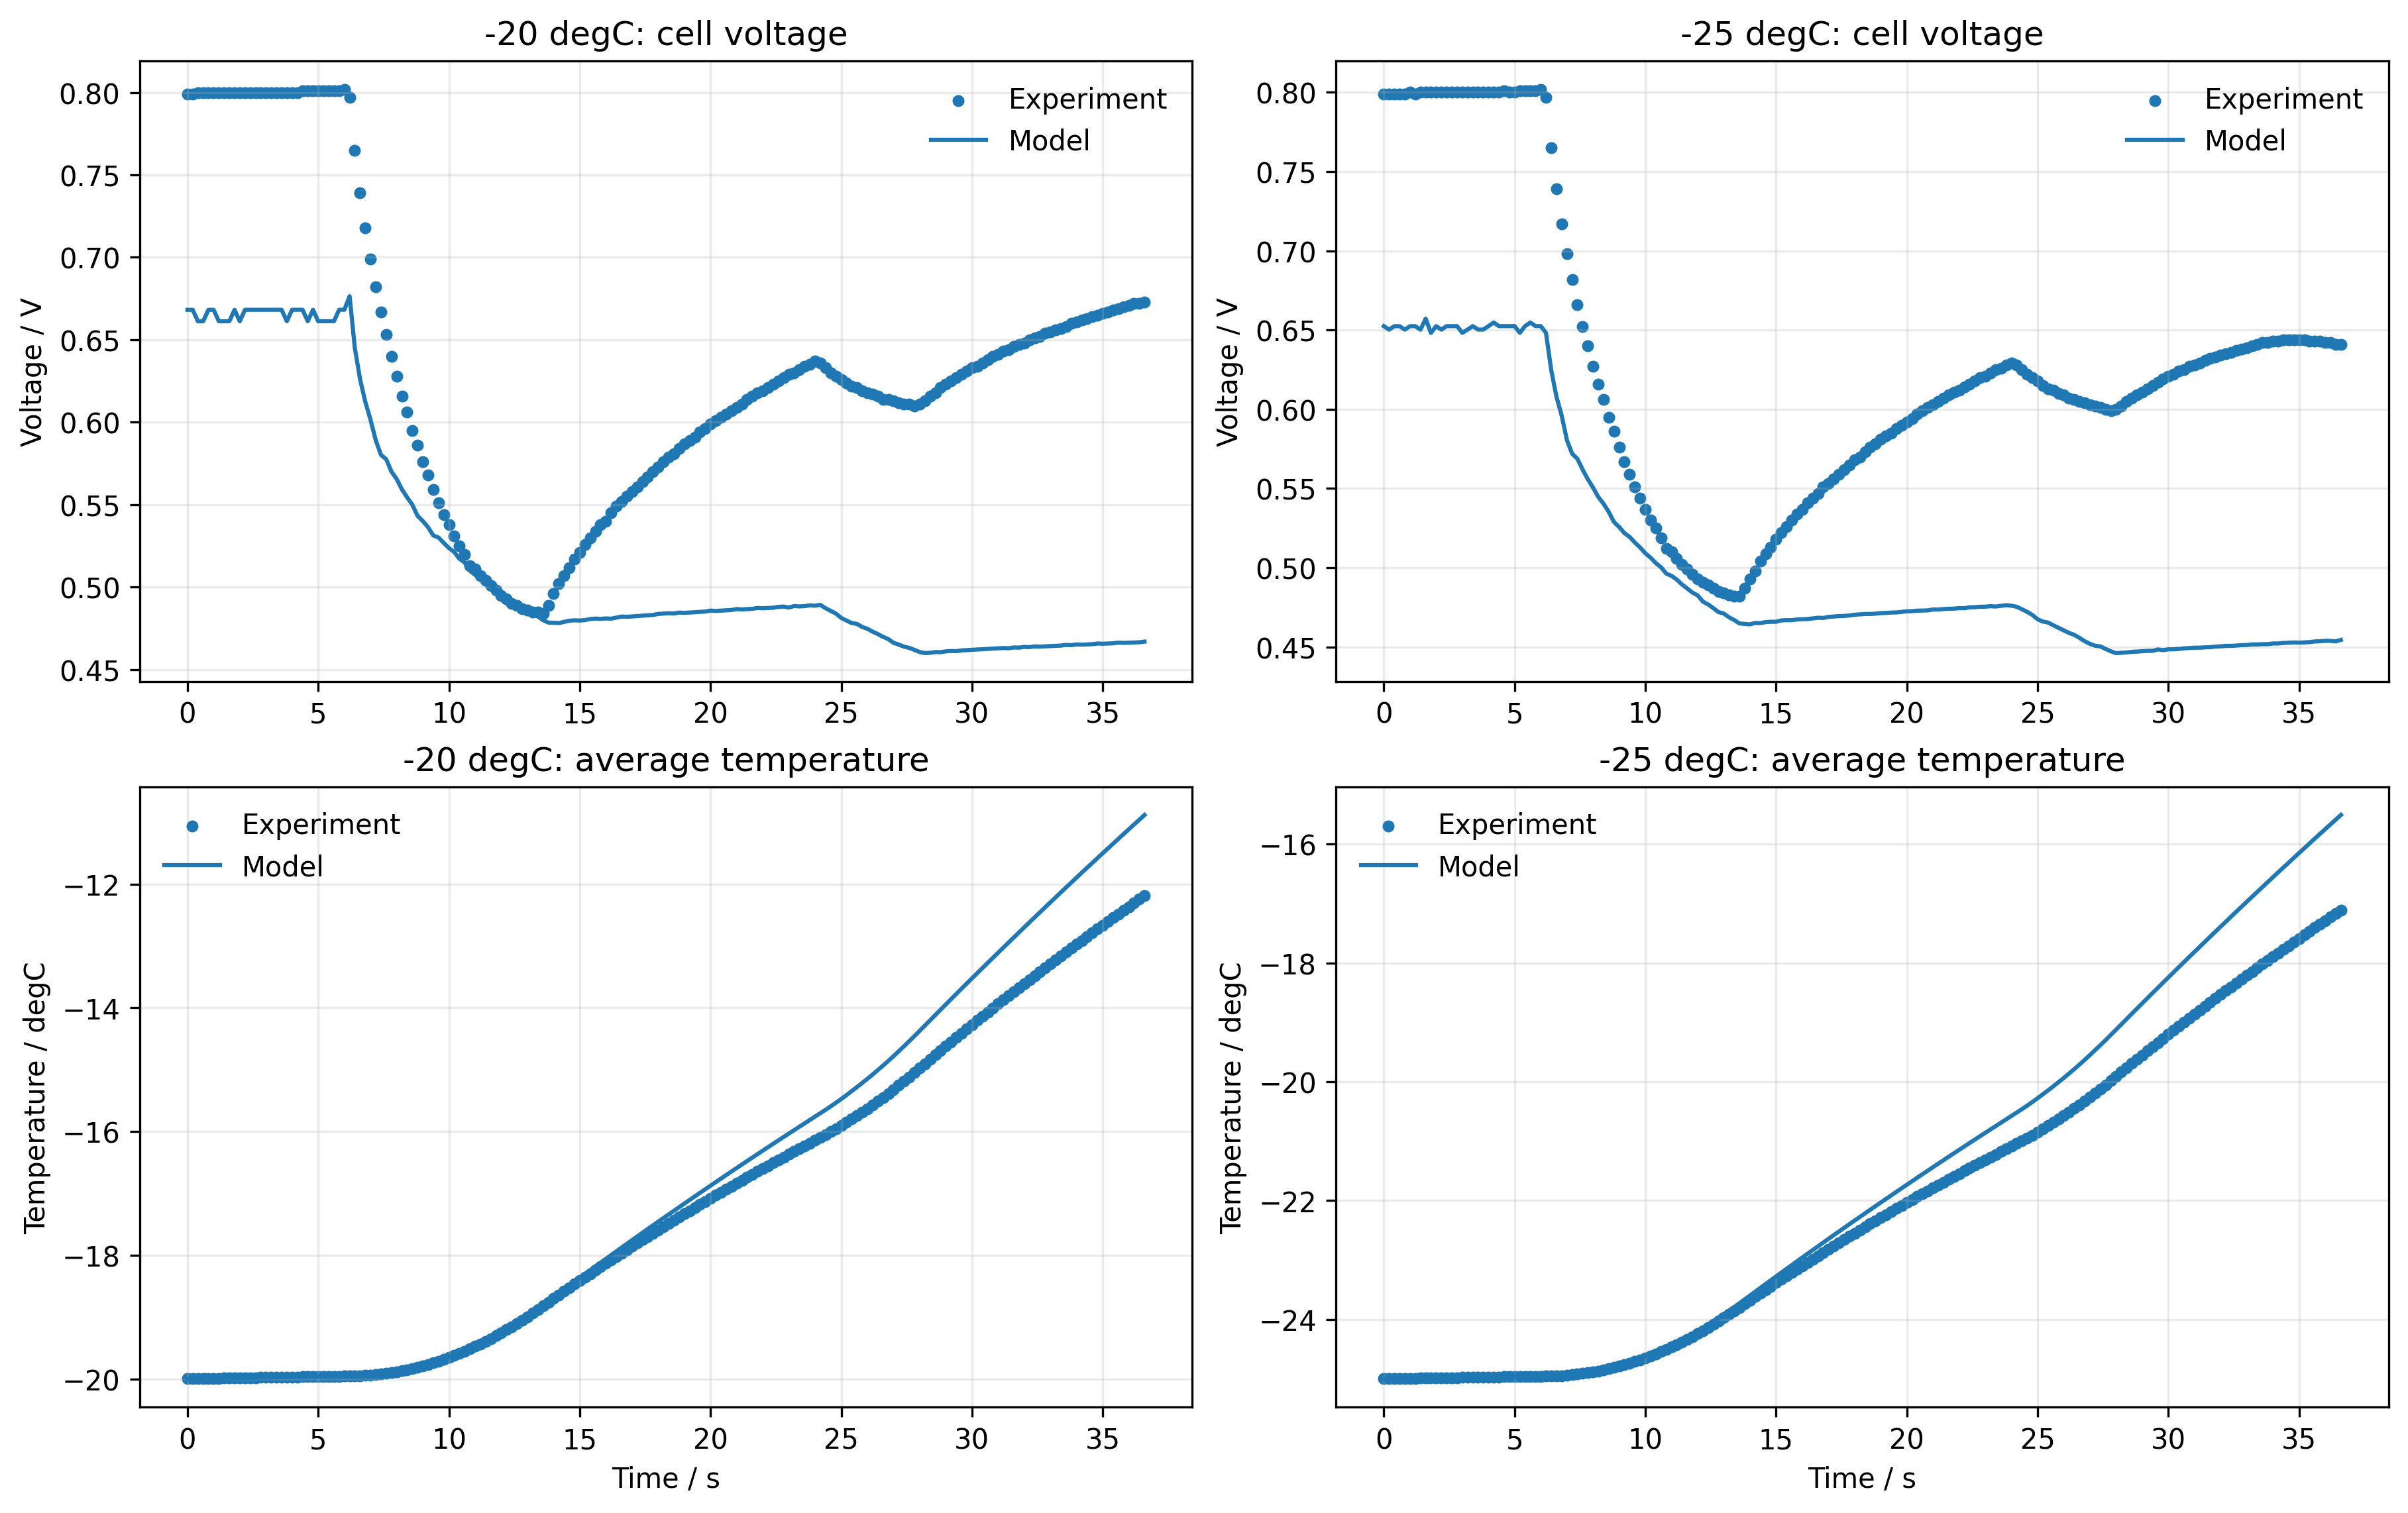

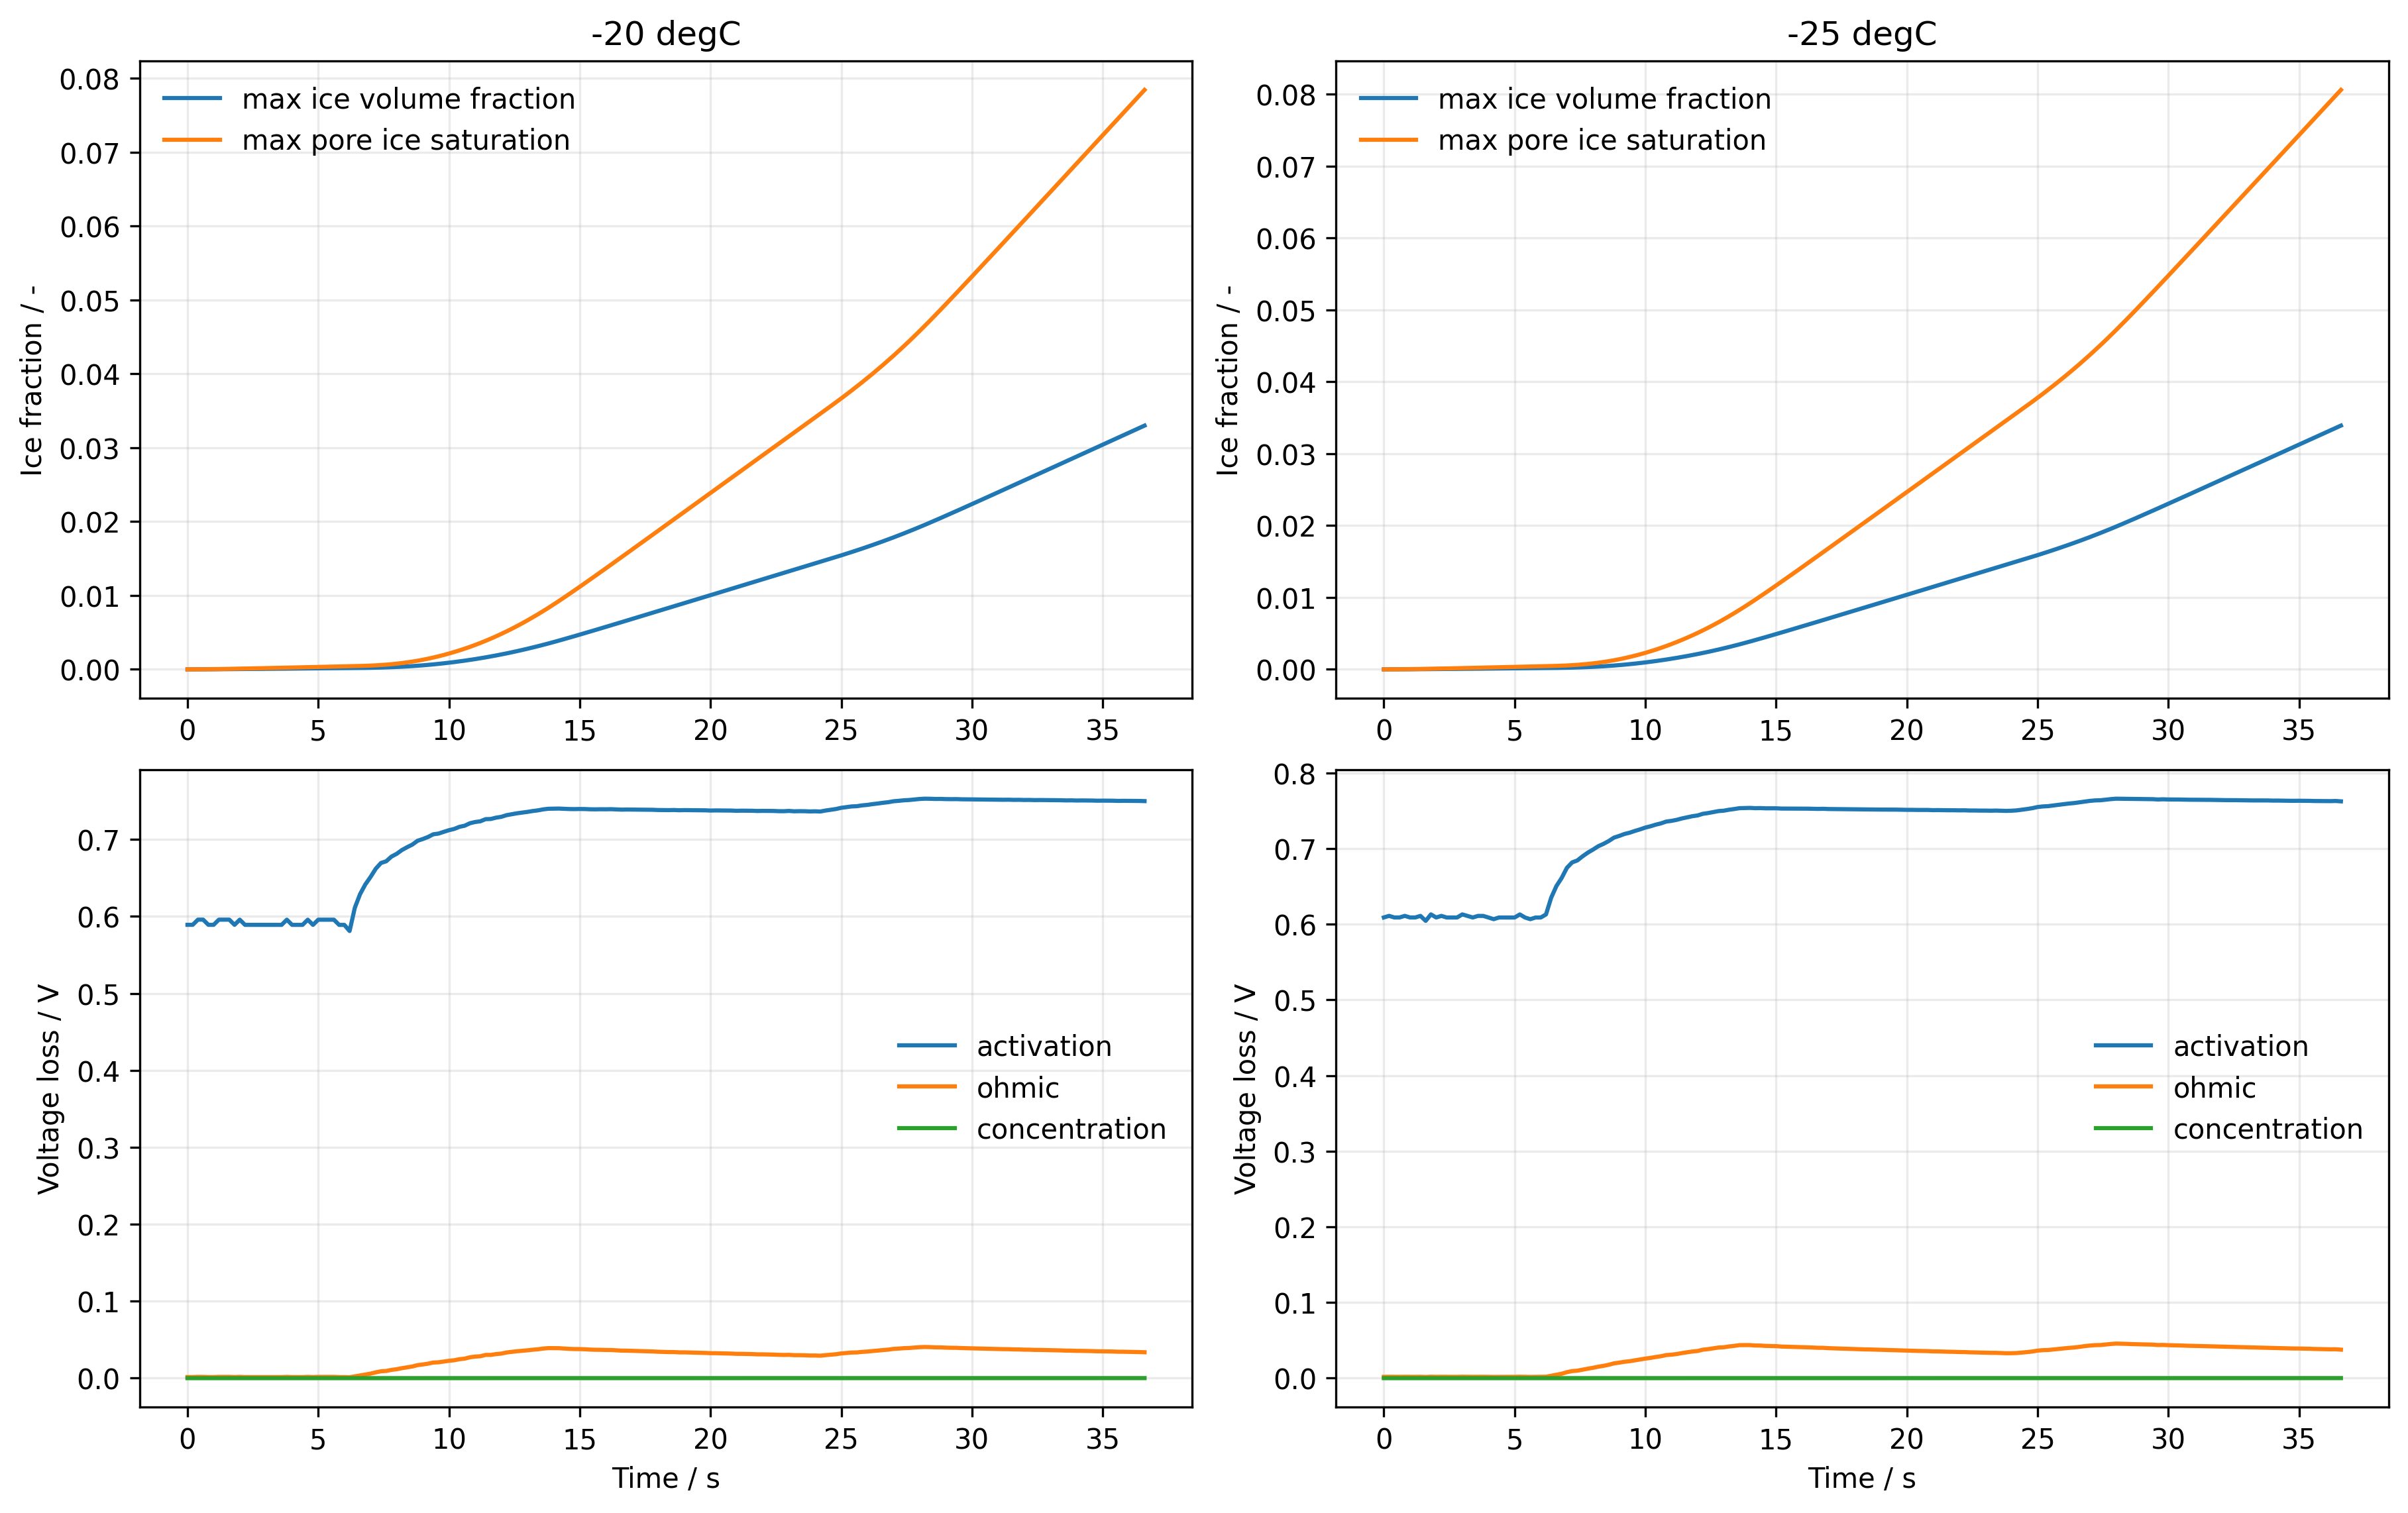

In [4]:
# DISPLAY_SAVED_FIGURES
[str(path) for path in figure_paths]


## 校准建议

建议只用 $-20\,^{\circ}\mathrm{C}$ 工况校准参数，再固定全部参数，用$-25\,^{\circ}\mathrm{C}$ 工况进行独立验证。优先考察交换电流密度、接触电阻、附加面热容、相变速率以及反应产水相态分配；不得同时拟合两个验证工况后仍称为独立验证。